# Heart Disease Prediction Using ML
## Shreyas Ravi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv('cardio_train 2.csv', sep = ";")

#### Data Processing and Cleaning

In [3]:
df1.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [4]:
df1.shape

(70000, 13)

In [5]:
df1.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [6]:
df1.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [7]:
df2 = df1.copy()

In [8]:
# drop id column
df2 = df2.drop(columns=['id'])

In [9]:
# separating features and labels
X = df2.drop(columns=['cardio']).values #shape = (70000, 11)
y = df2['cardio'].values #shape (70000,)

In [10]:
#standardize features
X = (X-np.mean(X, axis=0))/np.std(X, axis=0)

#### Exploratory Analysis

##### Target Class Balance

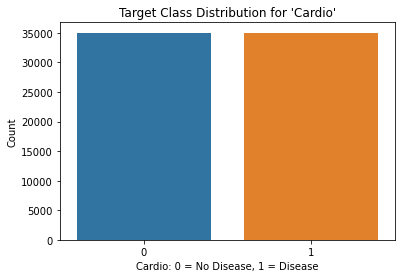

0    0.5003
1    0.4997
Name: cardio, dtype: float64


In [11]:
# begin with plotting 'cardio' which in this case is the target variable
sns.countplot(x=df2['cardio'])
plt.title("Target Class Distribution for 'Cardio'")
plt.xlabel("Cardio: 0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.show()

print(df2['cardio'].value_counts(normalize=True))

##### Feature Distributions

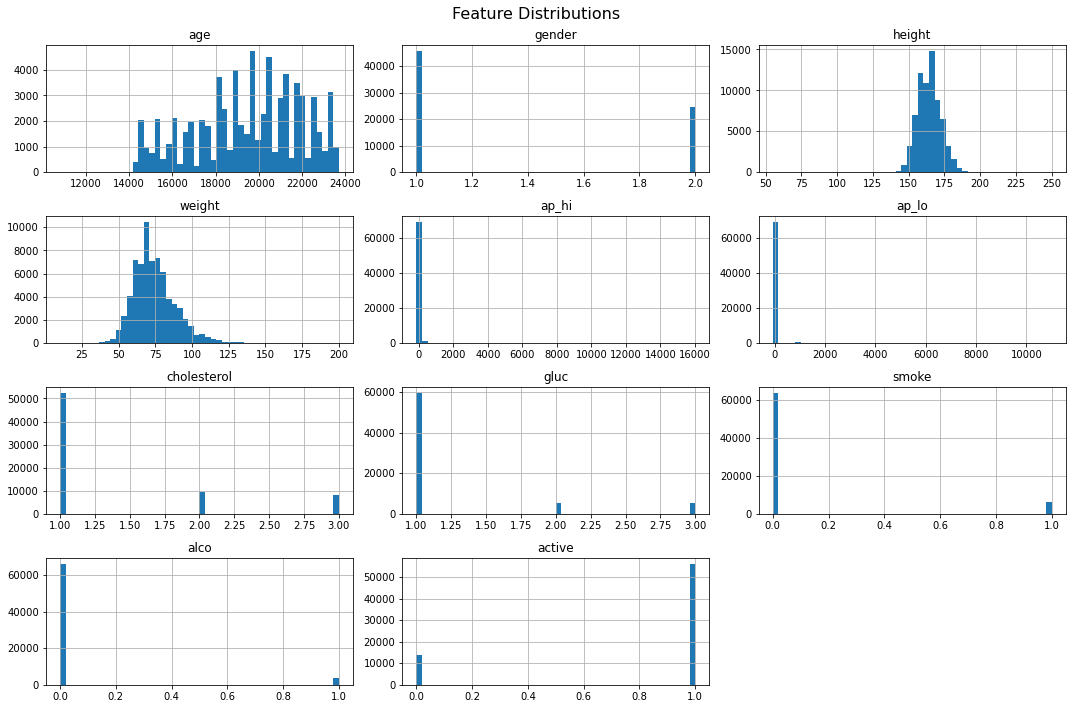

In [12]:
df2.drop(columns=['cardio']).hist(bins=50, figsize=(15,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
# convert age to years
df2['age'] = (df2['age']/365).astype(int)

In [14]:
print(df2['ap_hi'].describe())
print(df2['ap_lo'].describe())
print("ap_hi max:", df2['ap_hi'].max())
print("ap_hi min:", df2['ap_hi'].min())


count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64
count    70000.000000
mean        96.630414
std        188.472530
min        -70.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: ap_lo, dtype: float64
ap_hi max: 16020
ap_hi min: -150


In [15]:
# correcting seemingly incorrect values rather than dropping them
# fix clearly incorrect negative values
df2['ap_hi'] = df2['ap_hi'].apply(lambda x: abs(x) if x < 0 else x)
df2['ap_lo'] = df2['ap_lo'].apply(lambda x: abs(x) if x < 0 else x)

In [16]:
# fix unusually large values by assuming decimals got droppoed
df2['ap_hi'] = df2['ap_hi'].apply(lambda x: x/10 if x > 250 else x)
df2['ap_lo'] = df2['ap_lo'].apply(lambda x: x/10 if x > 200 else x)


In [17]:
df2 = df2[(df2['ap_hi'] >= 80) & (df2['ap_hi'] <= 240)]
df2 = df2[(df2['ap_lo'] >= 40) & (df2['ap_lo'] <= 140)]


In [18]:
df2.head(10)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110.0,80.0,1,1,0,0,1,0
1,55,1,156,85.0,140.0,90.0,3,1,0,0,1,1
2,51,1,165,64.0,130.0,70.0,3,1,0,0,0,1
3,48,2,169,82.0,150.0,100.0,1,1,0,0,1,1
4,47,1,156,56.0,100.0,60.0,1,1,0,0,0,0
5,60,1,151,67.0,120.0,80.0,2,2,0,0,0,0
6,60,1,157,93.0,130.0,80.0,3,1,0,0,1,0
7,61,2,178,95.0,130.0,90.0,3,3,0,0,1,1
8,48,1,158,71.0,110.0,70.0,1,1,0,0,1,0
9,54,1,164,68.0,110.0,60.0,1,1,0,0,0,0


In [19]:
df2.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,69682.000000,69682.000000,69682.000000,69682.000000,69682.000000,69682.000000,69682.000000,69682.000000,69682.000000,69682.000000,69682.000000,69682.000000
mean,52.843044,1.349588,164.360280,74.211709,127.011270,81.616956,1.367297,1.226429,0.088287,0.053687,0.803837,0.499670
std,6.766563,0.476843,8.191441,14.399079,17.052501,9.772055,0.680621,0.572237,0.283714,0.225400,0.397096,0.500003
min,29.000000,1.000000,55.000000,10.000000,80.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,2.000000,250.000000,200.000000,240.000000,140.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


##### Correlation Heatmap

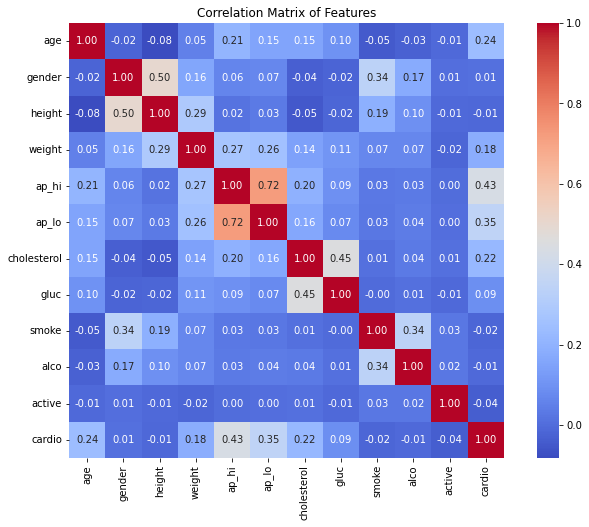

In [20]:
# compute correlation matrix
corr_matrix = df2.corr()

# heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True)
plt.title('Correlation Matrix of Features')
plt.show()

##### Principal Component Analysis for Dimensionality Reduction

In [21]:
# implementing Principal Component Analysis from scratch
def custom_pca(X, n_components=None):

    # step 1 - mean center the data
    X_centered = X - np.mean(X, axis=0)

    # step 2 - covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)

    # step 3 - eigenvalues and eigenvectors
    eigen_vals, eigen_vecs = np.linalg.eigh(cov_matrix)

    # step 4 - sort eigenvalues and eigenvectors
    sorted_idx = np.argsort(eigen_vals)[::-1]
    eigen_vals = eigen_vals[sorted_idx]
    eigen_vecs = eigen_vecs[:, sorted_idx]

    # step 5 - explained variance
    explained_variance = eigen_vals / np.sum(eigen_vals)

    # step 6 - select top components
    if n_components is not None:
        eigen_vecs = eigen_vecs[:, :n_components]
        X_reduced = np.dot(X_centered, eigen_vecs)
    else:
        X_reduced = np.dot(X_centered, eigen_vecs)

    return X_reduced, explained_variance


In [22]:
# Applying the pca and plotting explained variance

X_pca, explained_var = custom_pca(X)

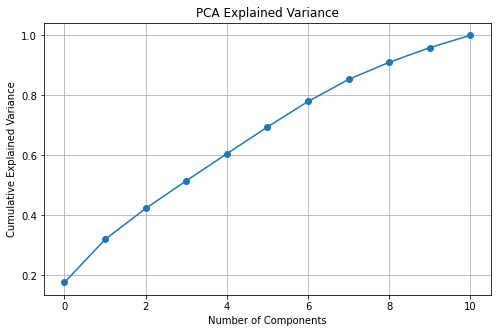

In [23]:
# plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_var), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

###### Since we'd like to keep 90% of the variance and still reduce dimensionality, we will retain 8 components.

In [24]:
X_pca_final, _ = custom_pca(X, n_components=8)

##### Data Splitting

In [25]:
from sklearn.model_selection import train_test_split

# split standardized features and labels - 70% train, 30% temp (test + val)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [26]:
# splitting temp to test and validation
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

In [27]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Validation:", X_val.shape)


Train: (49000, 11)
Test: (14000, 11)
Validation: (7000, 11)


#### Although earlier we ran a PCA on the entire data, we cannot use it as it would introduce data leakage, since we trained it on the test, training and validation sets. The above PCA was simply for exploratory purposes. We will now re-apply PCA on the training data and project.

In [28]:
def fit_pca(X, n_components):

    # compute mean of each feature column wise
    X_mean = np.mean(X, axis=0)

    # center data
    X_centered = X - X_mean

    # compute covariance matrix of centered data
    cov = np.cov(X_centered, rowvar=False)

    # perform eigen decomposition to get eigenvalues and eigenvectors
    eig_vals, eig_vecs = np.linalg.eigh(cov)

    # sort eigval and eigvec in descending order
    sorted_idx = np.argsort(eig_vals)[::-1]
    eig_vecs = eig_vecs[:, sorted_idx][:, :n_components]

    # return mean vector and the top n_components principal directions
    return X_mean, eig_vecs


In [29]:
X_mean_train, eig_vecs_train = fit_pca(X_train, n_components=8)

In [30]:
def project_pca(X, mean, eigenvectors):
    return np.dot(X - mean, eigenvectors)

# applying pca projection
X_train_pca = project_pca(X_train, X_mean_train, eig_vecs_train)
X_test_pca = project_pca(X_test, X_mean_train, eig_vecs_train)
X_val_pca = project_pca(X_val, X_mean_train, eig_vecs_train)


### Perceptron Implementation

In [31]:
# creating a perceptron function from scratch

# binary step function
def sign(x):
    'Returns 1 if the input is non negative and 0 if it is negative'
    return 1 if x >= 0 else 0

# perceptron
def perceptron_train(X, y, lr=0.01, epochs=1000, verbose=True):
    """trains a perceptron classifier using stochastic updates

    Parameters:
      - X: (n_samples, n_features) input feature matrix
      - y: (n_samples,) target labels (expected to be 0 or 1)
      - lr: learning rate (controls step size for weight updates)
      - epochs: number of passes over the training set
      - verbose: print accuracy and misclassifications every 50 epochs

    Returns:
      - w: learned weight vector
      - b: learned bias term
    """

    n_samples, n_features = X.shape
    w = np.zeros(n_features)  # initialize weights to 0
    b = 0  # same for bias

    # iterate over dataset for a number of epochs
    for epoch in range(epochs):
        misclassified = 0
        for i in range(n_samples):
            # compute weighted sum (linear output)
            linear_output = np.dot(X[i], w) + b

            # apply sign activation function for prediction
            y_pred = sign(linear_output)

            # calculate error between true and predicted
            error = y[i] - y_pred

            if error != 0:
                misclassified += 1

            # update rule: only apply if prediction was wrong
            # move weights in direction of reducing error
            w += lr * error * X[i]
            b += lr * error

        # accuracy logging
        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            predictions = perceptron_predict(X, w, b)
            acc = np.mean(predictions == y)
            print(f"Epoch {epoch+1:>4} | Accuracy: {acc:.4f} | Misclassified: {misclassified}")

    return w, b


In [32]:
def perceptron_predict(X, w, b):
    return np.array([sign(np.dot(x,w)+b) for x in X])

In [33]:
# training
# Actually train the model
w_p, b_p = perceptron_train(X_train_pca, y_train, lr=0.01, epochs=150, verbose=True)

Epoch    1 | Accuracy: 0.5670 | Misclassified: 19142
Epoch   11 | Accuracy: 0.6082 | Misclassified: 19217
Epoch   21 | Accuracy: 0.6093 | Misclassified: 19273
Epoch   31 | Accuracy: 0.5175 | Misclassified: 19257
Epoch   41 | Accuracy: 0.5406 | Misclassified: 19087
Epoch   51 | Accuracy: 0.5557 | Misclassified: 19209
Epoch   61 | Accuracy: 0.5238 | Misclassified: 19180
Epoch   71 | Accuracy: 0.5804 | Misclassified: 19205
Epoch   81 | Accuracy: 0.5271 | Misclassified: 19318
Epoch   91 | Accuracy: 0.5137 | Misclassified: 19164
Epoch  101 | Accuracy: 0.5544 | Misclassified: 19294
Epoch  111 | Accuracy: 0.4982 | Misclassified: 19068
Epoch  121 | Accuracy: 0.5811 | Misclassified: 19241
Epoch  131 | Accuracy: 0.5433 | Misclassified: 19236
Epoch  141 | Accuracy: 0.5559 | Misclassified: 19191
Epoch  150 | Accuracy: 0.5557 | Misclassified: 19131


In [34]:
y_pred_test = perceptron_predict(X_test_pca, w_p, b_p)


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, model_name="Model"):
    print(f"--- {model_name} Performance ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print()

# evaluate on test set
evaluate(y_test, y_pred_test, model_name="Single-Layer Perceptron (Test Set)")


--- Single-Layer Perceptron (Test Set) Performance ---
Accuracy : 0.5463571428571429
Precision: 0.5444643595753481
Recall   : 0.5644654088050315
F1 Score : 0.554284511193768



In [36]:
y_pred_val = perceptron_predict(X_val_pca, w_p, b_p)
evaluate(y_val, y_pred_val, model_name="Single-Layer Perceptron (Validation Set)")


--- Single-Layer Perceptron (Validation Set) Performance ---
Accuracy : 0.555
Precision: 0.551492336649637
Recall   : 0.5863350485991995
F1 Score : 0.5683802133850631



#### The Single Layer Perceptron's poor performance shows that the decision boundary for the data we feed it is not linearly separable, hence making it unable to capture complex non-linear relationships. To capture such relationships like that between blood pressure, cholesterol, age etc we need to extend our model to a multi-layer perceptron with nonlinear activations and inclusion of backpropagation.

#### The following highlights the Multi-Layer Perceptron Architecture

#### Input Layer - 8 Features (PCA Reduced)
#### Hidden Layer - 1 layer, 16 neurons, ReLU activation
#### Output Layer - 1 neuron, Sigmoid Activation
#### Loss - Binary Cross Entropy
#### - Optimizer - Gradient Descent

In [59]:
# defining Activation Function

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

# relu activation
def relu(x):
    return np.maximum(0, x)

# derivative of ReLU: 1 if x > 0, else 0
def relu_derivative(x):
    return (x > 0).astype(float)

# sigmoid act: outputs prob like values (0-1)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# derivative of sigmoid
def sigmoid_derivative(x):
    sx = sigmoid(x)
    return sx * (1 - sx)


In [65]:
def forward_backward(X, y, W1, b1, W2, b2, lr=0.01):
    """
    Performs forward and backward propagation on a 1-hidden-layer MLP and updates
    weights and biases using batch gradient descent

    Parameters:
    - X: input data matrix
    - y: true labels
    - W1, b1: weights and biases for hidden layer input
    - W2, b2: weights and biases for output layer
    - lr: learning rate

    Returns:
    - updated W1, b1, W2, b2
    - loss for current batch
    """

    m = X.shape[0]  # number of training examples
    y = y.reshape(-1, 1)  # ensure y is column vector

    ### FORWARD PASS ###

    # input to hidden layer
    Z1 = np.dot(X, W1) + b1  # linear comb (n_samples, n_hidden)
    A1 = tanh(Z1)            # tanh activation

    # hidden layer to output layer
    Z2 = np.dot(A1, W2) + b2  # linear combination (n_samples, 1)
    Z2 = np.clip(Z2, -500, 500)  # avoids extreme values causing overflow
    A2 = sigmoid(Z2)          # sigmoid activation

    # debug
    # print("Sigmoid output stats:", np.min(A2), np.max(A2), np.mean(A2))
    # print("y shape:", y.shape, "| dtype:", y.dtype)
    # print("A2 shape:", A2.shape)

    # LOSS CALCULATION

    epsilon = 1e-8
    A2 = np.clip(A2, epsilon, 1 - epsilon)  # avoid log(0) on A2
    loss = -np.mean(y * np.log(A2) + (1 - y) * np.log(1 - A2))  # binary cross entropy

    ### BACKWARD PASS ###

    # output layer gradients
    dZ2 = A2 - y                         # derivative of loss w.r.t output
    dW2 = np.dot(A1.T, dZ2) / m         # weight gradient for W2
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m  # bias gradient

    # hidden layer gradients
    dA1 = np.dot(dZ2, W2.T)             # backprop through W2
    dZ1 = dA1 * tanh_derivative(Z1)     # derivative of tanh
    dW1 = np.dot(X.T, dZ1) / m          # weight gradient for W1
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m  # bias gradient

    ### UPDATE PARAMETERS ###

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    return W1, b1, W2, b2, loss


In [66]:
def initialize_parameters(n_input, n_hidden, n_output):
    """
    Initializes weights and biases for a 1-hidden-layer neural network.

    Parameters:
    - n_input: number of input features (e.g., 8 after PCA)
    - n_hidden: number of neurons in the hidden layer
    - n_output: number of output neurons (1 for binary classification)

    """
    np.random.seed(42)  # for reproducibility

    # small random values for weights, zeros for biases
    W1 = np.random.randn(n_input, n_hidden) * 0.1
    b1 = np.zeros((1, n_hidden))

    W2 = np.random.randn(n_hidden, n_output) * 0.1
    b2 = np.zeros((1, n_output))

    return W1, b1, W2, b2


In [75]:
# training function
def train_mlp(X, y, hidden_size=16, lr=0.01, epochs=500, verbose=True):
    """
    Parameters:
    - X: input features
    - y: binary labels
    - hidden_size: number of hidden layer neurons
    - lr: learning rate
    - epochs: number of training passes
    - verbose: print loss every 50 epochs

    Returns:
    - Trained parameters: W1, b1, W2, b2
    """

    n_input = X.shape[1]  # number of input features
    n_output = 1          # binary classification → 1 output neuron with sigmoid

    # initialize weights and biases for both layers
    W1, b1, W2, b2 = initialize_parameters(n_input, hidden_size, n_output)

    # loop over dataset for no. epochs
    for epoch in range(epochs):

        # decay learning rate every 200 epochs
        if epoch % 200 == 0 and epoch > 0:
            lr *= 0.9

        # perform forward and backward pass → update params accordingly
        W1, b1, W2, b2, loss = forward_backward(X, y, W1, b1, W2, b2, lr)

        # verbose mode - print loss every 50 epochs
        if verbose and (epoch % 50 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1:>4} | Loss: {loss:.4f}")

    return W1, b1, W2, b2


In [76]:
X_debug = X_train_pca[:49000].astype(np.float64)
y_debug = y_train[:49000].astype(np.float64)

W1, b1, W2, b2 = train_mlp(X_debug, y_debug, hidden_size=64, lr=0.001, epochs=2000)


Epoch    1 | Loss: 0.6924
Epoch   51 | Loss: 0.6902
Epoch  101 | Loss: 0.6881
Epoch  151 | Loss: 0.6861
Epoch  201 | Loss: 0.6842
Epoch  251 | Loss: 0.6825
Epoch  301 | Loss: 0.6809
Epoch  351 | Loss: 0.6793
Epoch  401 | Loss: 0.6778
Epoch  451 | Loss: 0.6765
Epoch  501 | Loss: 0.6752
Epoch  551 | Loss: 0.6739
Epoch  601 | Loss: 0.6727
Epoch  651 | Loss: 0.6716
Epoch  701 | Loss: 0.6706
Epoch  751 | Loss: 0.6696
Epoch  801 | Loss: 0.6686
Epoch  851 | Loss: 0.6677
Epoch  901 | Loss: 0.6669
Epoch  951 | Loss: 0.6661
Epoch 1001 | Loss: 0.6653
Epoch 1051 | Loss: 0.6645
Epoch 1101 | Loss: 0.6638
Epoch 1151 | Loss: 0.6632
Epoch 1201 | Loss: 0.6625
Epoch 1251 | Loss: 0.6619
Epoch 1301 | Loss: 0.6613
Epoch 1351 | Loss: 0.6607
Epoch 1401 | Loss: 0.6602
Epoch 1451 | Loss: 0.6597
Epoch 1501 | Loss: 0.6592
Epoch 1551 | Loss: 0.6587
Epoch 1601 | Loss: 0.6582
Epoch 1651 | Loss: 0.6578
Epoch 1701 | Loss: 0.6574
Epoch 1751 | Loss: 0.6570
Epoch 1801 | Loss: 0.6566
Epoch 1851 | Loss: 0.6562
Epoch 1901 |

In [80]:
def mlp_predict(X, W1, b1, W2, b2):
    """
    Performs a forward pass through the trained MLP and returns binary predictions.

    Parameters:
    - X: input features
    - W1, b1: weights and bias for hidden layer
    - W2, b2: weights and bias for output layer

    """
    Z1 = np.dot(X, W1) + b1
    A1 = tanh(Z1)  
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    return (A2 >= 0.5).astype(int).flatten()


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, model_name="Model"):
    """
    Evaluates the performance of a binary classifier.

    Parameters:
    - y_true: ground truth labels (0 or 1)
    - y_pred: predicted labels (0 or 1)
    - model_name: name to print with results

    Prints:
    - Accuracy, Precision, Recall, and F1 Score
    """
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")
    print()


In [82]:
y_pred_test = mlp_predict(X_test_pca, W1, b1, W2, b2)
evaluate(y_test, y_pred_test, model_name="MLP (Test Set)")

y_pred_val = mlp_predict(X_val_pca, W1, b1, W2, b2)
evaluate(y_val, y_pred_val, model_name="MLP (Validation Set)")


--- MLP (Test Set) Performance ---
Accuracy : 0.6203
Precision: 0.6224
Recall   : 0.6106
F1 Score : 0.6165

--- MLP (Validation Set) Performance ---
Accuracy : 0.6170
Precision: 0.6169
Recall   : 0.6164
F1 Score : 0.6166



#### We will now move on to implementing the SVM after which we compare the results of all three models to see which one works the best with this data

In [83]:
# Convert 0 to -1 for SVM labels
y_train_svm = np.where(y_train == 0, -1, 1)
y_test_svm = np.where(y_test == 0, -1, 1)
y_val_svm = np.where(y_val == 0, -1, 1)


In [84]:
def initialize_svm_params(n_features):
    """
    Initialize weight and bias for the linear SVM
    
    Parameters:
    - n_features: number of input features
    
    Returns:
    - w: weight vector (initialized to zeros)
    - b: bias term (initialized to zero)
    
    """
    
    w = np.zeros(n_features)
    b = 0.0
    return w, b

In [85]:
def train_svm(X, y, lr=0.001, C=1.0, epochs=1000, verbose=True):
    """
    
    Trains a linear Support Vector Machine using batch gradient descent
    
    Parameters:
        - X: Input features
        - y: labels
        - lr: learning rate
        - C: regularization strength
        - epochs: number of training iterations
        - verbose: print loss every 100 epochs
        
    Returns:
        - w: learned weight vector 
        - b: learned bias term
        
    
    """
    
    n_samples, n_features = X.shape
    w, b = initialize_svm_params(n_features) # init weights and bias
    
    for epoch in range(epochs):
        #compute margin for each sample: y_1 * (w^t x_i + b)
        margins = y * (np.dot(X, w) + b)
        
        # identify where hinge loss is active 
        condition = margins < 1
        
        # gradient of reg term ∇(1/2 ||w||²) = w
        # gradient of hinge loss: ∇(C * sum(hinge loss)) = -C * y_i * x_i (for margin < 1)
        dw = w - C * np.dot(X[condition].T, y[condition]) / n_samples
        db = -C * np.sum(y[condition]) / n_samples
        
        # update weights and bias using gradient descent
        w -= lr * dw
        b -= lr * db
        
        #printing loss
        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
            hinge_loss = np.mean(np.maximum(0, 1-margins)) # mean hinge loss across samples
            total_loss = 0.5 * np.dot(w, w) + C * hinge_loss # total loss
            print(f"Epoch {epoch+1:>4} | Loss: {total_loss:.4f}")

    return w, b

In [86]:
def svm_predict(X, w, b):
    """
    
    Predicts binary class labels using a trained linear SVM and returns binary predictions (0 or 1)
    
    """
    linear_output = np.dot(X, w) + b
    return np.where(linear_output >= 0, 1, 0) # convert from {-1,1} to {0, 1}


In [87]:
# train svm
w_svm, b_svm = train_svm(X_train_pca, y_train_svm, lr=0.001, C=1.0, epochs=1000)


Epoch    1 | Loss: 1.0000
Epoch  101 | Loss: 0.9859
Epoch  201 | Loss: 0.9744
Epoch  301 | Loss: 0.9650
Epoch  401 | Loss: 0.9574
Epoch  501 | Loss: 0.9512
Epoch  601 | Loss: 0.9461
Epoch  701 | Loss: 0.9420
Epoch  801 | Loss: 0.9386
Epoch  901 | Loss: 0.9359
Epoch 1000 | Loss: 0.9337


In [88]:
# predicting
y_pred_test_svm = svm_predict(X_test_pca, w_svm, b_svm)
y_pred_val_svm = svm_predict(X_val_pca, w_svm, b_svm)

# evaluation
evaluate(y_test, y_pred_test_svm, model_name="SVM (Test Set)")
evaluate(y_val, y_pred_val_svm, model_name="SVM (Validation Set)")


--- SVM (Test Set) Performance ---
Accuracy : 0.6379
Precision: 0.6552
Recall   : 0.5813
F1 Score : 0.6161

--- SVM (Validation Set) Performance ---
Accuracy : 0.6344
Precision: 0.6509
Recall   : 0.5789
F1 Score : 0.6128

